In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition  import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix

### 1. Load the MNIST dataset directly from OpenML

In [81]:
mnist = fetch_openml("mnist_784")
# print(mnist.DESCR)

In [82]:
# mnist.feature_names, mnist.target_names 
mnist.data.shape, mnist.target.shape
print(f"Data shape: {mnist.data.shape}")

Data shape: (70000, 784)


In [83]:
mnist_df = pd.DataFrame(mnist.data, columns=mnist.feature_names)
mnist_df.head(5)

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [84]:
X = mnist_df
y = mnist.target

### 2. Standardizing the MNIST Dataset

In [85]:
scaler = StandardScaler().fit(X)  # set mean to 0 and unit variance
X_scaled = scaler.transform(X)

print(f"mean: {X_scaled.mean(axis=0)[:10]}")
print(f"variance: {X_scaled.std(axis=0)[:10]}")
X_scaled[:5]


mean: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
variance: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5, 784))

### 3. Applying PCA for Dimensionality Reduction

In [86]:
# PCA to reduce dimensionality 
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

In [87]:
# Convert X_pca to Pandas DataFrame
pca_columns = [f"PC{i+1}" for i in range(X_pca.shape[1])]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns)
X_pca_df.head(-5)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
0,-0.891720,-4.929711,-0.093038,8.064180,0.751001,1.051980,-0.283377,1.423696,-1.168523,2.406929,...,2.052139,1.682468,1.263031,-0.171619,-3.677793,-2.844284,-0.293259,2.185120,2.311110,-1.536142
1,8.813530,-7.517560,-3.714185,1.766171,-0.891472,-5.107950,0.134795,3.197223,-0.238224,-1.003382,...,1.446823,-0.331237,-0.939723,-0.184568,-0.916601,0.845018,0.393294,0.613290,0.246403,1.458619
2,2.204835,9.824461,-5.752488,-1.479673,-4.397900,2.507393,-18.927843,3.888938,2.443365,-0.145296,...,4.597722,-8.405998,-3.790641,3.828318,2.331770,1.022546,1.798620,-4.545477,-2.408932,2.568692
3,-6.534627,-4.029669,3.524017,0.218098,-5.606259,3.493731,-1.445046,-4.683887,-0.613930,-2.533648,...,-0.488539,0.665976,0.547718,0.208558,-1.294453,0.968222,-0.306078,0.266776,0.171302,0.056373
4,-5.251618,3.278848,-6.182219,-1.462658,1.667989,-0.580801,0.565828,-3.129538,0.005915,-0.972611,...,1.291463,0.136477,-0.295636,-0.259190,-3.001916,1.313263,-1.078107,-0.138995,0.747492,0.078171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69990,-6.299362,3.033052,-3.664012,2.475882,-1.836312,4.462638,6.487622,3.236851,-2.355564,-4.567270,...,0.475340,0.530743,-0.517915,-1.341516,-0.080503,-0.410585,-1.010208,-0.287945,0.798511,-0.335542
69991,1.579526,-0.705059,1.781224,9.746842,7.340029,2.207312,3.185634,-1.754268,3.412308,-5.392365,...,1.261300,-2.308745,-0.159293,1.650817,0.331139,-0.992407,-0.330542,-0.719119,1.511883,0.751695
69992,0.900793,0.000384,-9.099387,-2.126348,4.926283,1.024704,0.564652,-0.553306,0.575304,2.163621,...,-1.500658,0.389744,0.670996,-1.323979,-0.642497,0.077348,0.061754,-0.342424,-1.729208,0.261328
69993,19.060391,-10.040804,-5.871117,2.803705,-3.881838,-2.909324,3.320198,-1.342786,8.383950,-3.697340,...,0.989331,-2.652189,1.854493,-0.216930,-0.364492,-0.571782,-1.273957,-0.187746,1.406915,0.467999


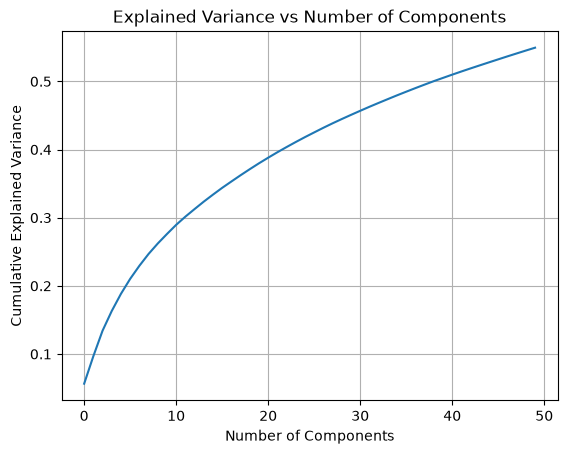

In [88]:
# Explained variance to check how much variance is retained
explained_variance = pca.explained_variance_ratio_.cumsum()
plt.plot(explained_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs Number of Components")
plt.grid()
plt.show()

### Applying K-Means for Clustering

In [89]:
# Apply K-Means on the PCA-reduced data
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans.fit(X_pca)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](10, 50)"

In [90]:
# Get cluster labels
cluster_labels = kmeans.labels_
cluster_labels

array([8, 6, 5, ..., 9, 8, 2], shape=(70000,), dtype=int32)

In [91]:
y

0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Name: class, Length: 70000, dtype: category
Categories (10, str): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [92]:
y_numeric = y.astype(int)
y_numeric

0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Name: class, Length: 70000, dtype: int64

In [93]:
confusion_mat = confusion_matrix(y_numeric, cluster_labels)
confusion_mat

array([[  87,   21,  674,  927,   34,   13, 4005,  409,  727,    6],
       [  13,    6,   15,   26, 7623,    1,    0,    8,  181,    4],
       [2586,  167,  635,  743,  832,   58,   44, 1773,  117,   35],
       [ 256,  183,   96, 4386,  673,  124,   13, 1123,  204,   83],
       [  50, 4021,  137,    4,  541,  469,   52,   25,  921,  604],
       [ 137,  325,  124, 2075,  531,   79,   36,  149, 2780,   77],
       [ 753,   38, 5129,   59,  506,    6,  240,    9,  135,    1],
       [   7, 1619,    3,   10,  542,  899,   20,   14,  126, 4053],
       [ 103,  384,   45, 2259, 1271,  104,   47,   74, 2378,  160],
       [  14, 3525,    6,  114,  353,  512,   43,   14,  141, 2236]])

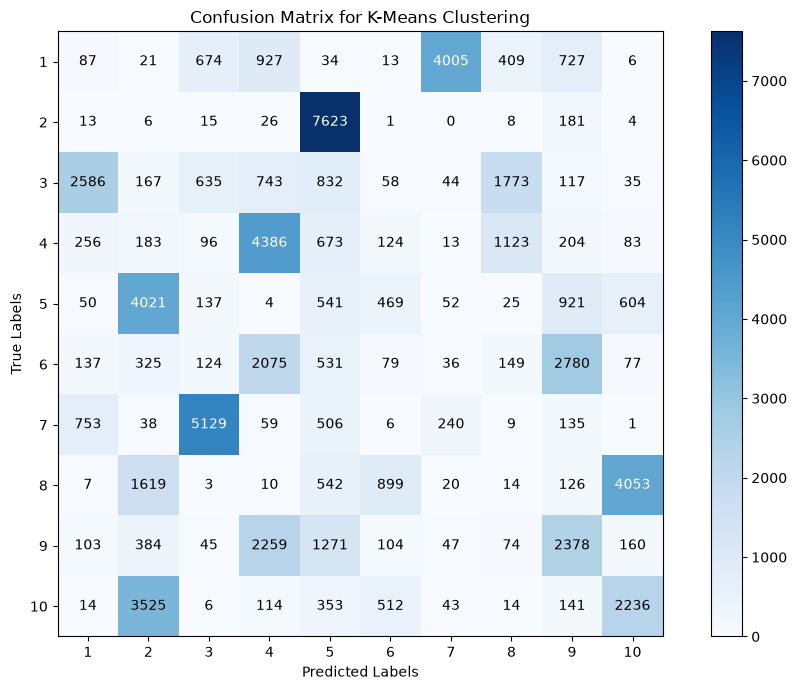

In [94]:
# Compute and visualize the confusion matrix
fig, ax = plt.subplots(figsize=(10,7))

# Display matrix
cax = ax.matshow(confusion_mat, cmap="Blues")

# Add colorbar
fig.colorbar(cax)

# Define lagels from 1 to 10
labels = [str(i) for i in range(1, 11)]

# Set tick positions (0-9) and display labels ('1' - '10')
ax.set_xticks(range(10))
ax.set_xticklabels(labels)
ax.set_yticks(range(10))
ax.set_yticklabels(labels)

# Set labels and Titles
plt.title("Confusion Matrix for K-Means Clustering")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

ax.xaxis.set_ticks_position("bottom")

# Annotate each cell with its count value
for i in range(confusion_mat.shape[0]):
    for j in range(confusion_mat.shape[1]):
        ax.text(j,i, str(confusion_mat[i, j]), ha="center", va="center",
                color="white" if confusion_mat[i, j] > confusion_mat.max()/2 else "black")

plt.tight_layout()
plt.show()

* ### Most Accurately Classified Digits:
    * Digit 4 leads with 4,386 correct prediction, followed by digit 9 (2,378), and digit 10 (2236). 
* ### Top misclassifications:
    1. Digit 2 is overwhelmingly misidentified as Digit 5 (7,623 instances, with only 6 correct predictions).
    2. Digit 7 is frequently misidentified as Digit 3 (5,129 instances).
    3. Digit 8 is frequently misidentified as Digit 10 (4,053 instances).
    4. Digit 1 is frequently misidentified as Digit 7 (4,005 instances).

Overall, the clustering/classification model struggles heavily with distinguishing specific digit pairs (particularly 2 vs. 5 and 7 vs. 3), indicating **high overlap in the feature space** for these classes.


### Cluster Visualization using PCA

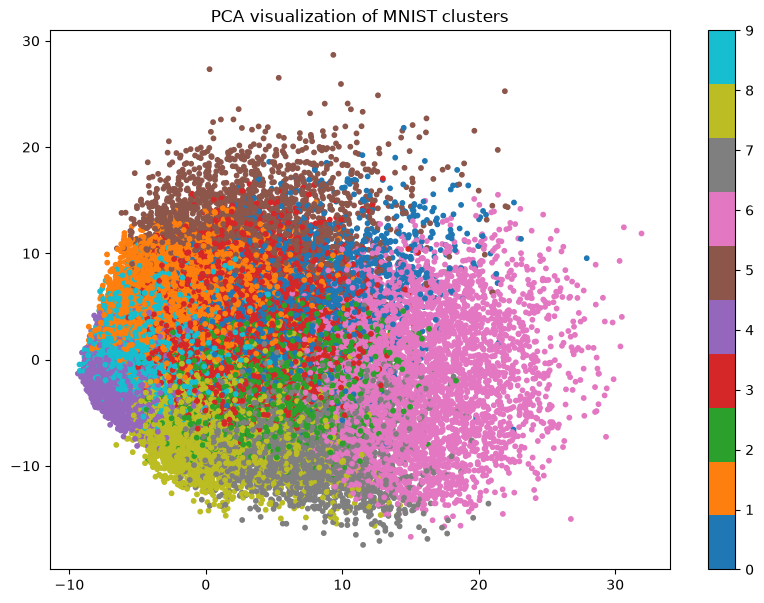

In [95]:
# Visualizing PC1 and PC2 in a 2-D plot
fig, ax = plt.subplots(figsize=(10,7))
sax = ax.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap="tab10", s=10)
fig.colorbar(sax)
plt.title("PCA visualization of MNIST clusters")
plt.show()

### Numpy Implementation of Principal Component Analysis (PCA)

- `mnist`: dataset
- `mnist_df`: dataset in Pandas DataFrame
- `X`: feature dataset
- `y`: label for the dataset

In [96]:
# implementing `StandadrdScaler` from `sklearn.preprocessing` module
# z = (x-u)/x where 'u' is th mean of the training samples,
# s is the standard deviation of the training samples
X_man = X.to_numpy()
X_mean = np.mean(X_man, axis=0)
X_mean[0]

np.float64(0.0)

In [97]:
X_std = np.std(X_man, axis=0)

# Replace 0 std values with 1 to avoid dividing by zero
X_std[X_std == 0] = 1
X_std[0], X_std.shape

(np.float64(1.0), (784,))

In [98]:
X_scaled_man = (X_man-X_mean)/X_std
X_scaled_man[:5]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5, 784))

In [99]:
# Make sure both datasets have same values
np.all(X_scaled == X_scaled_man)

np.True_

### 3. Applying PCA for Dimensional Reduction using `numpy`

In [100]:
X_scaled_man.shape

(70000, 784)

$\Sigma$ = $\frac{1}{N-1}X^{T}X$

In [101]:
# 1. Get feature covariance matrix (DxD) where D is the
# is the number of feature covariance matrix (784 in this case)
N = X_scaled_man.shape[0]
X_covar = np.matmul(X_scaled_man.T, X_scaled_man)/(N-1)  #(784x70_000)@(70_000x784)
X_covar[:5], X_covar.shape

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(5, 784)),
 (784, 784))

In [102]:
# 2. Compute Eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(X_covar)


In [103]:
eigenvectors.shape, eigenvalues.shape

((784, 784), (784,))

In [104]:
# 3. Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]  # P matrix


In [105]:
# 4. Project the scaled data onto the 
# eigenvectors to get the Principal Components
X_pca_man = np.matmul(X_scaled_man, eigenvectors) # (70_000x784)@(784x784) 
X_pca_man[:2]

array([[-8.91719847e-01+0.j,  4.92971090e+00+0.j,  9.30375793e-02+0.j,
        ..., -1.06421796e-13+0.j, -3.75539781e-14+0.j,
         9.33268451e-14+0.j],
       [ 8.81353003e+00+0.j,  7.51756046e+00+0.j,  3.71418494e+00+0.j,
        ...,  3.39491488e-15+0.j, -3.81910416e-14+0.j,
         6.11654928e-14+0.j]], shape=(2, 784))

In [106]:
X_pca_man.shape, X_pca_man[:,:50].shape, X_pca.shape, eigenvalues.shape

((70000, 784), (70000, 50), (70000, 50), (784,))

In [107]:
np.allclose(np.abs(X_pca), np.abs(X_pca_man[:, :50]))

True

### Variance 

In [108]:
# 1. Calculate the explained variance ratio for all components
explained_variance_ratio = eigenvalues/np.sum(eigenvalues)

# 2. Calculate the cumulative variance ratio
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)



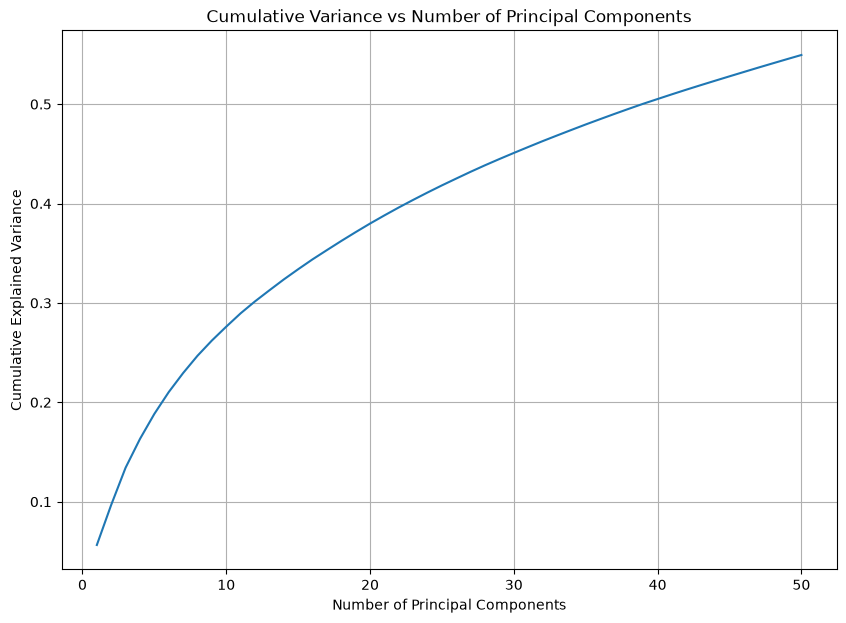

In [109]:
fig, ax = plt.subplots(figsize=(10,7))

k = 50
x = list(range(1, k+1))
y = cumulative_variance_ratio[:k]

ax.plot(x, y.real)

ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("Cumulative Variance vs Number of Principal Components")

ax.grid(True)


### Applying K-Means for Clustering

In [110]:
# Apply K-means on the PCA-reduced data
kmeans_2 = KMeans(n_clusters=10, random_state=42)
kmeans_2.fit(X_pca_man.real)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](10, 784)

In [111]:
cluster_labels_2 = kmeans_2.labels_
cluster_labels_2

array([1, 9, 5, ..., 6, 1, 3], shape=(70000,), dtype=int32)

In [112]:
# showing that confusion matrix derived from PCA class is same as the 
# one we derived manually using numpy 

confusion_mat_2 = confusion_matrix(y_numeric, cluster_labels_2)
confusion_mat_2

array([[  36,  331,   10,  309,  112,    9,    8,  945, 1468, 3675],
       [7646,  150,    9,   17,   14,    1,    6,    9,   25,    0],
       [ 832,   49,  184,  834, 2390,   38,   34, 1878,  719,   32],
       [ 565,   88,  198,   83,  794,   97,   97, 1159, 4050,   10],
       [ 536,  902, 3904,  129,   85,  304,  875,   33,    4,   52],
       [ 460, 2606,  304,   94,  262,   56,   94,  225, 2181,   31],
       [ 575,   94,   28, 5325,  388,    5,    1,   30,  123,  307],
       [ 517,  156, 1500,    3,   16,  939, 4123,   13,    9,   17],
       [1164, 1962,  334,   34,  225,   65,  215,  112, 2670,   44],
       [ 327,  123, 3444,    5,   23,  365, 2485,   18,  126,   42]])

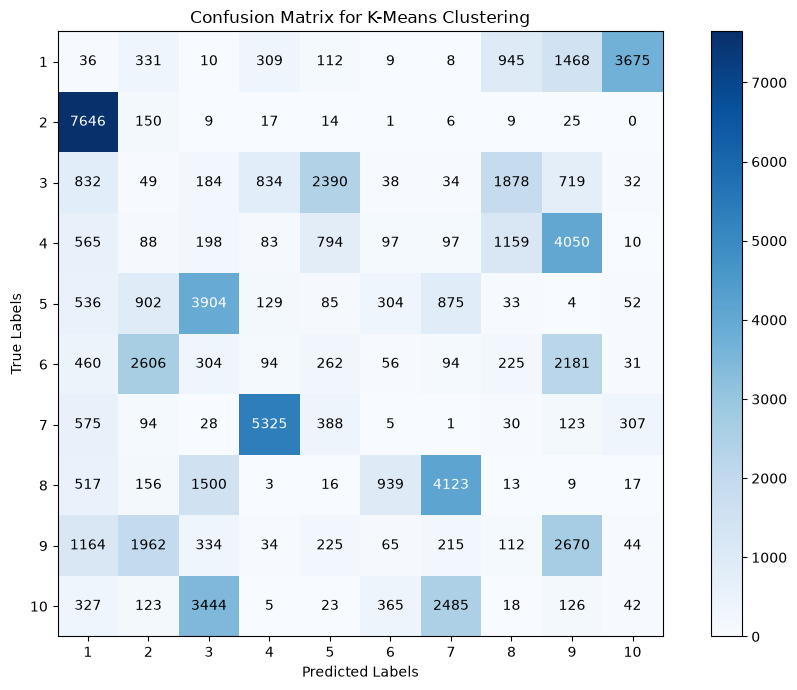

In [113]:
# Compute and visualize the confusion matrix
fig, ax = plt.subplots(figsize=(10,7))

# Display matrix
cax = ax.matshow(confusion_mat_2, cmap="Blues")

# Add colorbar
fig.colorbar(cax)

# Define lagels from 1 to 10
labels = [str(i) for i in range(1, 11)]

# Set tick positions (0-9) and display labels ('1' - '10')
ax.set_xticks(range(10))
ax.set_xticklabels(labels)
ax.set_yticks(range(10))
ax.set_yticklabels(labels)

# Set labels and Titles
plt.title("Confusion Matrix for K-Means Clustering")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

ax.xaxis.set_ticks_position("bottom")

# Annotate each cell with its count value
for i in range(confusion_mat_2.shape[0]):
    for j in range(confusion_mat_2.shape[1]):
        ax.text(j,i, str(confusion_mat_2[i, j]), ha="center", va="center",
                color="white" if confusion_mat_2[i, j] > confusion_mat_2.max()/2 else "black")

plt.tight_layout()
plt.show()

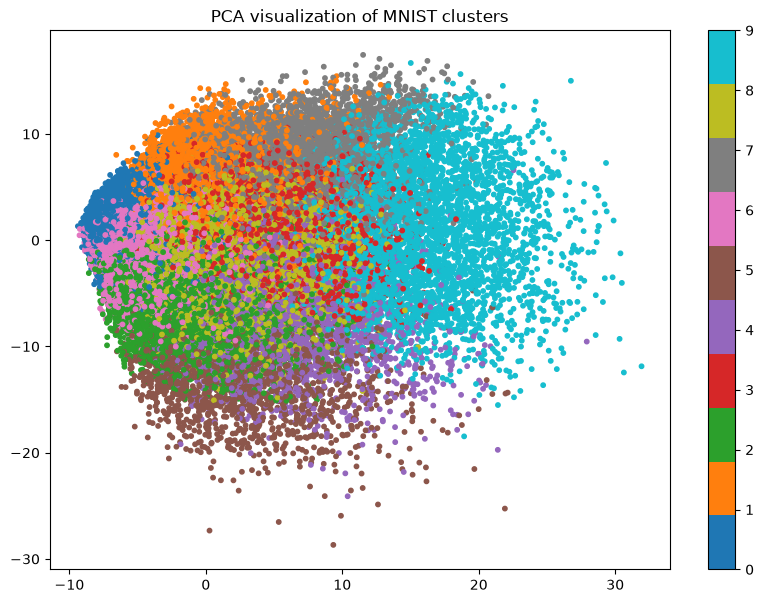

In [114]:
# Visualizing PC1 and PC2 in a 2-D plot
fig, ax = plt.subplots(figsize=(10,7))
sax = ax.scatter(X_pca_man[:,0].real, X_pca_man[:,1].real, c=cluster_labels_2, cmap="tab10", s=10)
fig.colorbar(sax)
plt.title("PCA visualization of MNIST clusters")
plt.show()